# Exercise 8
**Cristina Correa - 1819211867**


Update the script to emulate the following graph, and let the
starting point be in Sunderland and the end point be Washington

```
⭕-2-⭕      A — 2 — F
 |\   |       |\      |
 2 3  2       2 \     2
 |  \ |       |   3   |
⭕  `⭕      B    `— S
 |    |       |       |
 3    3       3       3
 |    |       |       |
⭕ 2 ⭕      C — 2 — D
```


In [24]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx


# Class representing a node in the graph
class Node:
    def __init__(self, name, heuristic_cost):
        self.name = name
        self.heuristic_cost = heuristic_cost
        self.adjacent = {}
        self.parent = None
        self.g_cost = float("inf")

    def add_neighbor(self, neighbor, cost):
        self.adjacent[neighbor] = cost

    def __lt__(self, other):
        return self.g_cost + self.heuristic_cost < other.g_cost + other.heuristic_cost

In [25]:
# A* search algorithm
def astar_search(start, goal):
    open_list = []
    closed_set = set()
    start.g_cost = 0
    heapq.heappush(open_list, start)

    while open_list:
        current_node = heapq.heappop(open_list)

        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node.name)
                current_node = current_node.parent
            return path[::-1]

        closed_set.add(current_node)

        for neighbor, cost in current_node.adjacent.items():
            tentative_g_cost = current_node.g_cost + cost

            if neighbor in closed_set and tentative_g_cost >= neighbor.g_cost:
                continue

            if tentative_g_cost < neighbor.g_cost or neighbor not in open_list:
                neighbor.g_cost = tentative_g_cost
                neighbor.parent = current_node
                if neighbor not in open_list:
                    heapq.heappush(open_list, neighbor)
    return None

In [26]:
# Creating nodes
A = Node("A", 3)
B = Node("B", 0)  # Washington
C = Node("C", 2)
D = Node("D", 1)
F = Node("F", 4)
S = Node("S", 2)  # Sunderland

# Adding neighbors and their costs
A.add_neighbor(F, 2)
A.add_neighbor(B, 2)
A.add_neighbor(S, 3)
B.add_neighbor(A, 2)
B.add_neighbor(C, 3)
C.add_neighbor(B, 3)
C.add_neighbor(D, 2)
D.add_neighbor(C, 2)
D.add_neighbor(S, 3)
S.add_neighbor(A, 3)
S.add_neighbor(F, 2)
S.add_neighbor(D, 3)
F.add_neighbor(A, 2)
F.add_neighbor(S, 2)

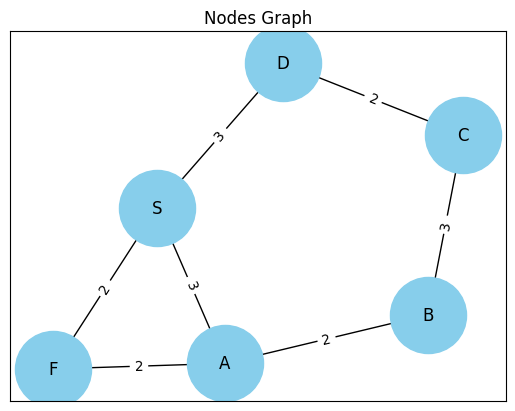

In [27]:
# Visualization without the solution
G = nx.Graph()
edges = [
    (A.name, F.name, {"weight": 2}),
    (A.name, B.name, {"weight": 2}),
    (A.name, S.name, {"weight": 3}),
    (B.name, C.name, {"weight": 3}),
    (C.name, D.name, {"weight": 2}),
    (D.name, S.name, {"weight": 3}),
    (F.name, S.name, {"weight": 2}),
]
G.add_edges_from(edges)

pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color="skyblue")
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Nodes Graph")
plt.show()

In [28]:
path = astar_search(S, B)
print("A* path:", path)

A* path: ['S', 'A', 'B']


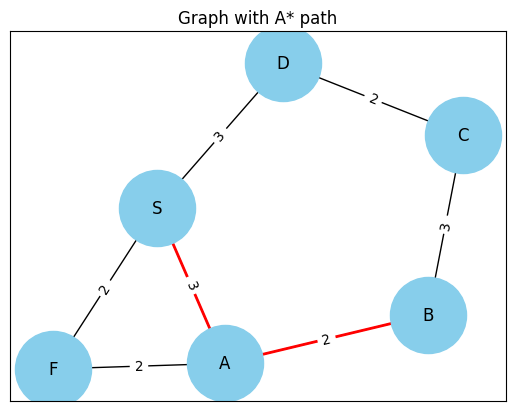

In [29]:
# Visualization with A* path
plt.title("Graph with A* path")
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color="skyblue")
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=[(path[i], path[i + 1]) for i in range(len(path) - 1)],
    edge_color="r",
    width=2,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.show()